In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
import warnings 
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("AIML Dataset.csv")


In [12]:
df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [13]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [14]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [17]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df.shape

(6362620, 11)

In [24]:
(df["isFraud"].value_counts()[1] / df.shape[0]) * 100

np.float64(0.12908204481801522)

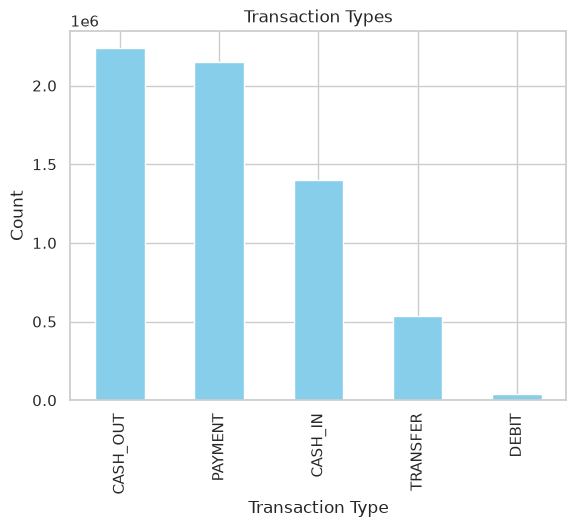

In [27]:
df["type"].value_counts().plot(kind="bar" , title="Transaction Types" , color = 'skyblue')
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

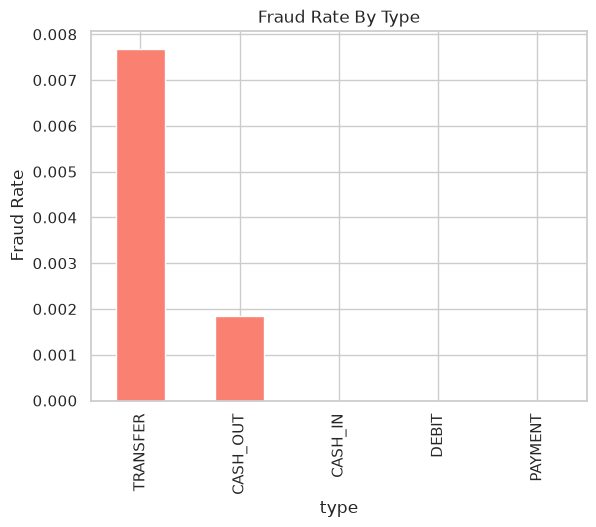

In [35]:
fraudByType = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraudByType.plot(kind="bar" ,  title="Fraud Rate By Type" , color = 'salmon')
plt.ylabel("Fraud Rate")
plt.show()

In [37]:
df["amount"].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

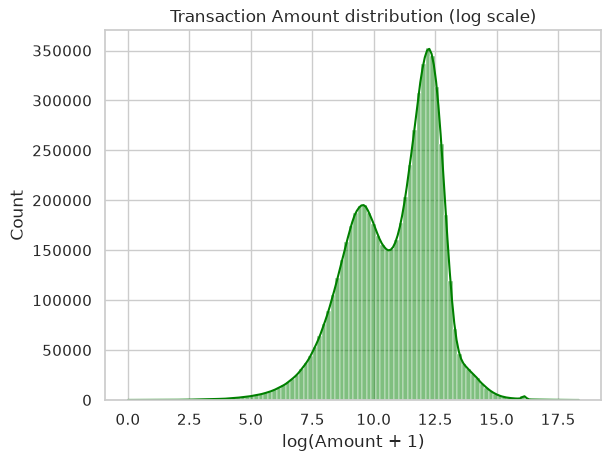

In [41]:
sns.histplot(np.log1p(df["amount"]), bins=100, kde=True, color='green')
plt.title("Transaction Amount distribution (log scale)")
plt.xlabel('log(Amount + 1)')
plt.show()

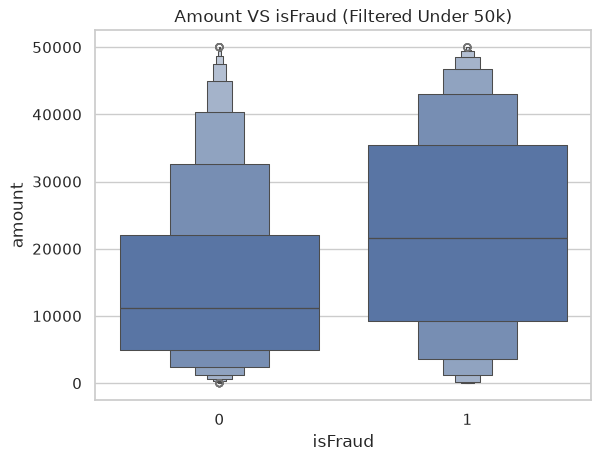

In [42]:
sns.boxenplot(data=df[df['amount'] < 50000] , x = 'isFraud' , y = 'amount')
plt.title("Amount VS isFraud (Filtered Under 50k)")
plt.show()

In [43]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [5]:
df["balanceDiffOrig"] = df["oldbalanceOrg"] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [46]:
(df['balanceDiffOrig'] < 0).sum()

np.int64(1399253)

In [47]:
(df['balanceDiffDest'] < 0).sum()

np.int64(1238864)

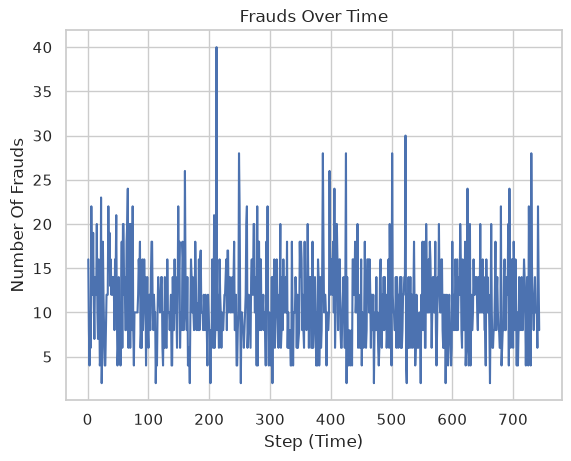

In [51]:
FraudsPerStep = df[df["isFraud"] == 1]["step"].value_counts().sort_index()
plt.plot(FraudsPerStep.index , FraudsPerStep.values , label = "Frauds per step ")
plt.xlabel("Step (Time)")
plt.ylabel("Number Of Frauds")
plt.title("Frauds Over Time")
plt.grid(True)
plt.show()

In [52]:
df.drop(columns="step" , inplace=True)

In [53]:
df.head(3)

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0


In [58]:
TopSenders = df['nameOrig'].value_counts().head(10)

In [59]:
TopSenders

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64

In [60]:
TopReceiver = df['nameDest'].value_counts().head(10)

In [61]:
TopReceiver

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [62]:
FraudUsers = df[df['isFraud'] == 1]['nameOrig'].value_counts().head(10)

In [66]:
FraudUsers

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
C1118430673    1
C749981943     1
C1334405552    1
C467632528     1
C1364127192    1
Name: count, dtype: int64

In [6]:
FraudTypes = df[df['type'].isin(['TRANSFER' , 'CASH_OUT'])]

In [7]:
FraudTypes['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

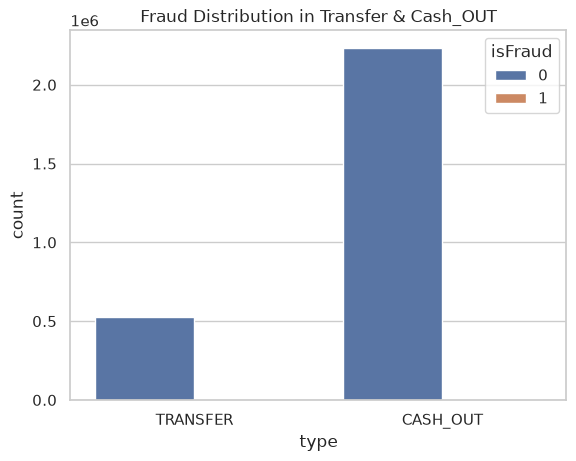

In [8]:
sns.countplot(data=FraudTypes , x='type' , hue='isFraud')
plt.title("Fraud Distribution in Transfer & Cash_OUT")
plt.show()

In [9]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud', 'balanceDiffOrig', 'balanceDiffDest'],
      dtype='str')

In [15]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

In [16]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


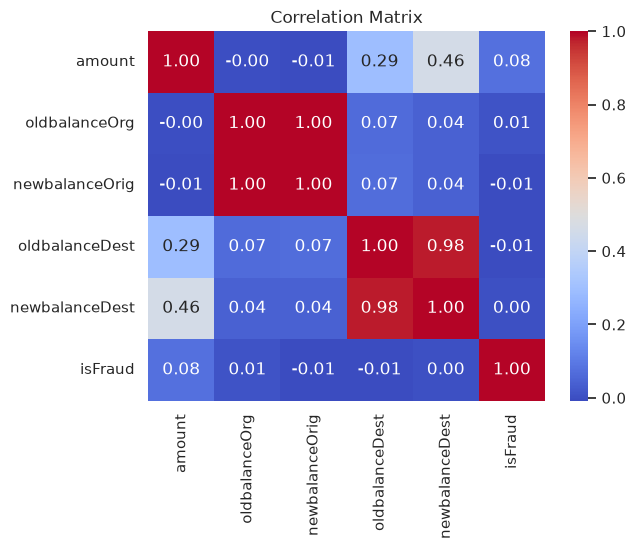

In [17]:
sns.heatmap(corr , annot =True , cmap='coolwarm' , fmt = '.2f')
plt.title('Correlation Matrix')
plt.show()

In [18]:
ZeroAfterTransfer = df[

    (df['oldbalanceOrg'] > 0)&
    (df['newbalanceOrig'] == 0 )&
    (df['type'].isin(['TRANSFER' , 'CASH_OUT']))
]

In [19]:
ZeroAfterTransfer

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,1,TRANSFER,181.00,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00
15,1,CASH_OUT,229133.94,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,46430.44
19,1,TRANSFER,215310.30,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00
24,1,TRANSFER,311685.89,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00
